# A 股风格因子全历史约束稳健性验证

**TL;DR：** 本 notebook 复核 2008–2026 raw/gross、constrained/gross、constrained/net 的机器产物、数据质量与晋级门槛。结论以 `promotion_decision.json` 为准，不在 notebook 中人工改写。

## 口径与边界

月末形成、下一交易日收盘尝试成交；多空两腿应用停牌、涨跌停、退市末端压力与实际成交名义成本。margin_secs 仅作融券资格上界。PIT v2 在 2026-08-02 之前属于 reconstructed PIT。

In [1]:
from pathlib import Path
import json
import os
import matplotlib.pyplot as plt
import pandas as pd
import warnings

warnings.filterwarnings('ignore', message='Glyph .* missing from font')
DATA_ROOT = Path(os.environ['DATA_PLATFORM_ROOT'])
OUTDIR = Path(os.environ.get(
    'STYLE_FACTOR_ROBUSTNESS_OUTDIR',
    DATA_ROOT / 'strategy_outputs/style-factors/20260802-full-constrained-validation',
))
assert OUTDIR.is_dir(), OUTDIR
comparison = pd.read_csv(OUTDIR / 'factor_robustness_comparison.csv')
wide = pd.read_csv(OUTDIR / 'factor_robustness_comparison_wide.csv')
gate = pd.read_csv(OUTDIR / 'promotion_gate.csv')
quality = pd.read_csv(OUTDIR / 'data_quality_checks.csv')
margin = pd.read_csv(OUTDIR / 'factor_margin_qualification_comparison.csv')
decision = json.loads((OUTDIR / 'promotion_decision.json').read_text())
meta = json.loads((OUTDIR / 'robustness_meta.json').read_text())
decision

{'schema_version': 'style_factor_robustness_promotion_gate.v1',
 'promotion_eligible': False,
 'decision': 'hold',
 'core_factors_required': ['size',
  'value',
  'momentum',
  'quality',
  'earnings_yield',
  'lowvol',
  'growth',
  'leverage',
  'beta',
  'liquidity'],
 'core_factors_passed': 5,
 'core_factors_failed': 5,
 'criteria': {'minimum_matched_coverage_ratio': 0.8,
  'direction': 'raw/gross, constrained/gross and constrained/net signs agree',
  'maximum_drawdown_degradation_percentage_points': 10.0,
  'cost_stability': 'constrained sign survives 10 bps and 30 bps',
  'delist_terminal_return': -0.5},
 'official_latest_action': 'keep_current_latest',
 'main_reports_action': 'keep_current_reports'}

In [2]:
# 数据质量：grain、覆盖、联结与复权桥必须全部通过。
assert quality['passed'].astype(bool).all(), quality.loc[~quality['passed'].astype(bool)]
assert meta['data']['duplicate_daily_keys'] == 0
assert meta['data']['duplicate_universe_keys'] == 0
assert meta['data']['universe_daily_join_rate'] >= 0.99
assert meta['data']['historical_revision_safe'] is False
quality

,check,observed,threshold,passed
0,daily_key_duplicates,0.000000,= 0,True
1,universe_key_duplicates,0.000000,= 0,True
2,margin_key_duplicates,0.000000,= 0,True
3,pit_panel_key_duplicates,0.000000,= 0,True
4,early_daily_basic_join_rate,0.999875,>= 99%,True
5,early_adj_factor_join_rate,1.000000,= 100%,True
6,early_limit_status_join_rate,0.999387,>= 99%,True
7,universe_daily_join_rate,0.990444,>= 99% (formation-date suspensions retained),True
8,adjustment_bridge_p99_abs_error_pct,0.004965,<= 0.10 percentage point,True
9,st_reconstruction_precision,1.000000,>= 99%,True


## 晋级门槛结果

覆盖率至少 80%，raw/gross、constrained/gross、constrained/net 同方向，净最大回撤恶化不超过 10 个百分点，且方向在 10/30 bps 下均不翻转。10 个核心因子必须全部通过。

In [3]:
gate[['factor', 'coverage_ratio', 'raw_annual_pct',
      'constrained_net_10bps_annual_pct', 'drawdown_degradation_pct',
      'factor_pass', 'failure_reason']]

,factor,coverage_ratio,raw_annual_pct,constrained_net_10bps_annual_pct,drawdown_degradation_pct,factor_pass,failure_reason
0,size,1.000000,-17.98,-19.13,0.53,True,NaN
1,value,1.000000,11.15,6.83,2.57,True,NaN
2,momentum,1.000000,-14.58,-21.53,4.35,True,NaN
3,quality,0.808492,1.24,-0.65,16.72,False,"direction,drawdown,cost"
4,earnings_yield,1.000000,3.72,0.29,13.14,False,"drawdown,cost"
5,lowvol,1.000000,8.60,2.85,15.75,False,"drawdown,cost"
6,growth,0.773631,7.61,2.64,6.46,False,coverage
7,leverage,0.773631,1.19,-0.25,13.06,False,"coverage,direction,drawdown,cost"
8,beta,0.976536,-7.02,-8.01,3.63,True,NaN
9,liquidity,1.000000,18.48,11.29,-0.59,True,NaN


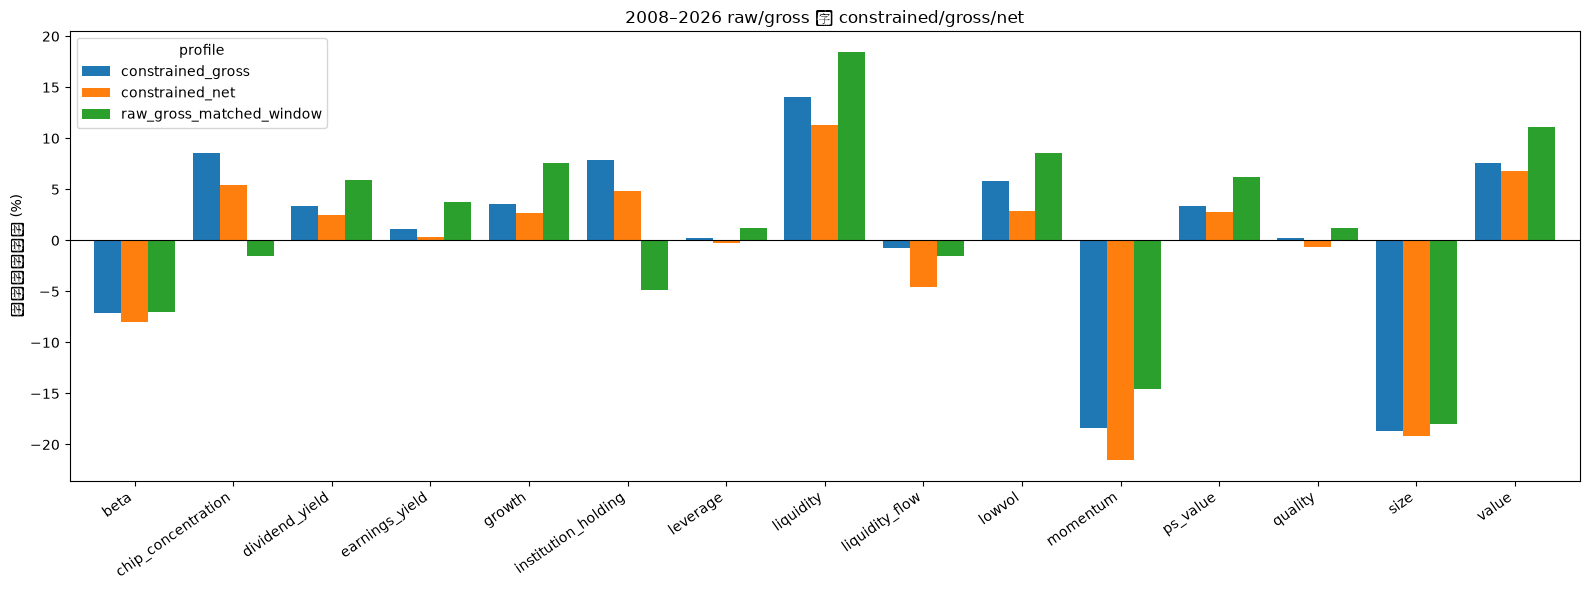

In [4]:
plot = comparison.pivot(index='factor', columns='profile', values='geometric_annual_ret')
ax = plot.plot.bar(figsize=(16, 6), width=0.82)
ax.axhline(0, color='black', linewidth=0.8)
ax.set(title='2008–2026 raw/gross 与 constrained/gross/net',
       xlabel='', ylabel='几何年化收益 (%)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 融券资格上界

该分支只把 bottom-quintile 空头候选与 margin_secs 形成日资格取交集。它不包含真实券源、借券费用、召回概率或可借数量。

In [5]:
margin.pivot(index='factor', columns='profile', values='geometric_annual_ret')

profile,constrained_net_matched_2015plus,margin_qualification_upper_bound_net
factor,,
beta,-8.43,-6.65
chip_concentration,5.38,5.59
dividend_yield,3.23,6.00
earnings_yield,1.29,2.71
growth,1.40,1.30
institution_holding,4.83,1.63
leverage,-2.09,-2.03
liquidity,11.08,9.09
liquidity_flow,-4.55,-9.20


In [6]:
latest = (DATA_ROOT / 'strategy_outputs/style-factors/latest.txt').read_text().strip()
assert decision['decision'] == 'hold'
assert latest == '20260730-full-value'
{'decision': decision['decision'], 'passed': decision['core_factors_passed'],
 'failed': decision['core_factors_failed'], 'official_latest': latest}

{'decision': 'hold',
 'passed': 5,
 'failed': 5,
 'official_latest': '20260730-full-value'}